## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
import tensorflow as tf
tf.reset_default_graph()

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

### Find no.of samples are there in training and test datasets

In [115]:
x_test.shape


(10000, 28, 28)

In [116]:
y_test.shape

(10000,)

In [117]:
x_train.shape

(60000, 28, 28)

### Find dimensions of an image in the dataset

In [118]:
x_test[0:28:28].shape

(1, 28, 28)

In [119]:
y_test[0]

9

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
trainY = tf.keras.utils.to_categorical(y_train, num_classes=10)


In [0]:
testY= tf.keras.utils.to_categorical(y_test,num_classes=10)

In [122]:
trainY[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

In [123]:
testY[250]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_train=x_train/255

In [0]:
x_test=x_test/255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_train=x_train.reshape(x_train.shape[0],28,28,1).astype('float32')

In [127]:
x_train.shape

(60000, 28, 28, 1)

In [128]:
x_test.shape

(10000, 28, 28)

In [0]:
x_test=x_test.reshape(x_test.shape[0],28,28,1).astype('float32')

### Import the necessary layers from keras to build the model

In [0]:
tf.keras.backend.clear_session()
model=tf.keras.models.Sequential()


### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [0]:
model.add(tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu')) # Conv layer 1 
model.add(tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu')) # Conv Layer 2
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
pa=tf.keras.callbacks.EarlyStopping(monitor='val_loss',min_delta=0,patience=5,verbose=0,mode='auto',baseline=None,restore_best_weights=False)

In [101]:
model.fit(x_train,trainY,validation_data=(x_test,testY), epochs=10,callbacks=[pa],batch_size=30)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 12s 208us/sample - loss: 0.5946 - acc: 0.7898 - val_loss: 0.3558 - val_acc: 0.8708
Epoch 2/10
60000/60000 [==============================] - 8s 141us/sample - loss: 0.2843 - acc: 0.8962 - val_loss: 0.3033 - val_acc: 0.8889
Epoch 3/10
60000/60000 [==============================] - 9s 144us/sample - loss: 0.2159 - acc: 0.9207 - val_loss: 0.2584 - val_acc: 0.9097
Epoch 4/10
60000/60000 [==============================] - 8s 142us/sample - loss: 0.1668 - acc: 0.9387 - val_loss: 0.2877 - val_acc: 0.9056
Epoch 5/10
60000/60000 [==============================] - 8s 141us/sample - loss: 0.1252 - acc: 0.9539 - val_loss: 0.3037 - val_acc: 0.9087
Epoch 6/10
60000/60000 [==============================] - 9s 143us/sample - loss: 0.0921 - acc: 0.9659 - val_loss: 0.3487 - val_acc: 0.9065
Epoch 7/10
60000/60000 [==============================] - 9s 142us/sample - loss: 0.0671 - acc: 0.9758 - val_

In [102]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              multiple                  320       
_________________________________________________________________
conv2d_1 (Conv2D)            multiple                  9248      
_________________________________________________________________
flatten (Flatten)            multiple                  0         
_________________________________________________________________
dense (Dense)                multiple                  2359424   
_________________________________________________________________
dense_1 (Dense)              multiple                  1290      
_________________________________________________________________
dense_2 (Dense)              multiple                  110       
Total params: 2,370,392
Trainable params: 2,370,392
Non-trainable params: 0
______________________________________________

### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [177]:
tf.keras.backend.clear_session()
model1=tf.keras.models.Sequential()
model1.add(tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu')) # Conv layer 1 
model1.add(tf.keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu')) # Conv Layer 2
model1.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(tf.keras.layers.Dropout(0.25))
model1.add(tf.keras.layers.Flatten())
model1.add(tf.keras.layers.Dense(128, activation='relu'))
model1.add(tf.keras.layers.Dense(10, activation='softmax'))
model1.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
model1.fit(x_train,trainY,validation_data=(x_test,testY), epochs=10,callbacks=[pa],batch_size=30)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 8s 133us/sample - loss: 0.4004 - acc: 0.8559 - val_loss: 0.3105 - val_acc: 0.8868
Epoch 2/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.2616 - acc: 0.9043 - val_loss: 0.2600 - val_acc: 0.9017
Epoch 3/10
60000/60000 [==============================] - 7s 120us/sample - loss: 0.2136 - acc: 0.9204 - val_loss: 0.2358 - val_acc: 0.9150
Epoch 4/10
60000/60000 [==============================] - 7s 122us/sample - loss: 0.1766 - acc: 0.9341 - val_loss: 0.2613 - val_acc: 0.9048
Epoch 5/10
60000/60000 [==============================] - 7s 123us/sample - loss: 0.1501 - acc: 0.9439 - val_loss: 0.2212 - val_acc: 0.9227
Epoch 6/10
60000/60000 [==============================] - 7s 123us/sample - loss: 0.1286 - acc: 0.9518 - val_loss: 0.2389 - val_acc: 0.9176
Epoch 7/10
60000/60000 [==============================] - 7s 123us/sample - loss: 0.1097 - acc: 0.9585 - val_l

In [151]:
model1.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              multiple                  320       
_________________________________________________________________
conv2d_1 (Conv2D)            multiple                  9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) multiple                  0         
_________________________________________________________________
dropout (Dropout)            multiple                  0         
_________________________________________________________________
flatten (Flatten)            multiple                  0         
_________________________________________________________________
dense (Dense)                multiple                  589952    
_________________________________________________________________
dense_1 (Dense)              multiple                  1

### Now, to the above model, lets add Data Augmentation 

In [0]:
import matplotlib.pyplot as plt
import numpy as np
datagen= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True, validation_split=0.2)
datagen.fit(x_train)

### Import the ImageDataGenrator from keras and fit the training images

In [180]:
model1.fit_generator(datagen.flow(x_train, trainY, batch_size=30),
                    steps_per_epoch=len(x_train)/30,epochs=20,validation_data=(x_test,testY))


Epoch 1/20
2000/2000 [==============================] - 18s 9ms/step - loss: 0.3979 - acc: 0.8522 - val_loss: 0.3149 - val_acc: 0.8866
Epoch 2/20
2000/2000 [==============================] - 19s 9ms/step - loss: 0.3894 - acc: 0.8566 - val_loss: 0.3163 - val_acc: 0.8852
Epoch 3/20
2000/2000 [==============================] - 18s 9ms/step - loss: 0.3879 - acc: 0.8563 - val_loss: 0.3419 - val_acc: 0.8815
Epoch 4/20
2000/2000 [==============================] - 18s 9ms/step - loss: 0.3880 - acc: 0.8569 - val_loss: 0.3326 - val_acc: 0.8809
Epoch 5/20
2000/2000 [==============================] - 18s 9ms/step - loss: 0.3799 - acc: 0.8599 - val_loss: 0.3072 - val_acc: 0.8880
Epoch 6/20
2000/2000 [==============================] - 19s 9ms/step - loss: 0.3775 - acc: 0.8607 - val_loss: 0.3055 - val_acc: 0.8908
Epoch 7/20
2000/2000 [==============================] - 18s 9ms/step - loss: 0.3743 - acc: 0.8615 - val_loss: 0.3158 - val_acc: 0.8886
Epoch 8/20
2000/2000 [==============================] -

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

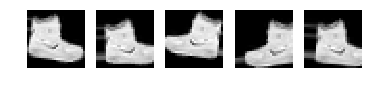

In [181]:
from matplotlib import pyplot as plt
gen = datagen.flow(x_train[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

###  Report the final train and validation accuracy

In [0]:
Accuracy_Test=model1.evaluate(x_test,testY,verbose=0)

In [185]:
print(Accuracy_Test)

[0.302196318256855, 0.8934]


In [187]:
Accuracy_Train=model1.evaluate(x_train,trainY,verbose=0)
print(Accuracy_Train)

[0.26961240238447987, 0.90185]


## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [194]:
from keras.datasets import cifar10


(x_train1,y_train1),(x_test1,y_test1)=cifar10.load_data()

170500096/170498071 [==============================] - 2s 0us/step


### **Load CIFAR10 dataset**

In [0]:
# Done on the above steps #

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

In [0]:
datagen1= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True, validation_split=0.2)


### **Prepare/fit the generator.**

In [0]:
datagen.fit(x_train1)

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

In [0]:
x_train1=x_train1/255

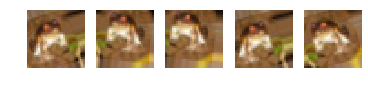

In [199]:
from matplotlib import pyplot as plt
gen = datagen1.flow(x_train1[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()